In [3]:
from datasets import load_dataset
ds = load_dataset("CADCODER/GenCAD-Code", num_proc=16, split=["train", "test"], cache_dir="/Volumes/BIG-DATA/HUGGINGFACE_CACHE")

d:\CV\mecagent-technical-test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import matplotlib.pyplot as plt
import numpy as np

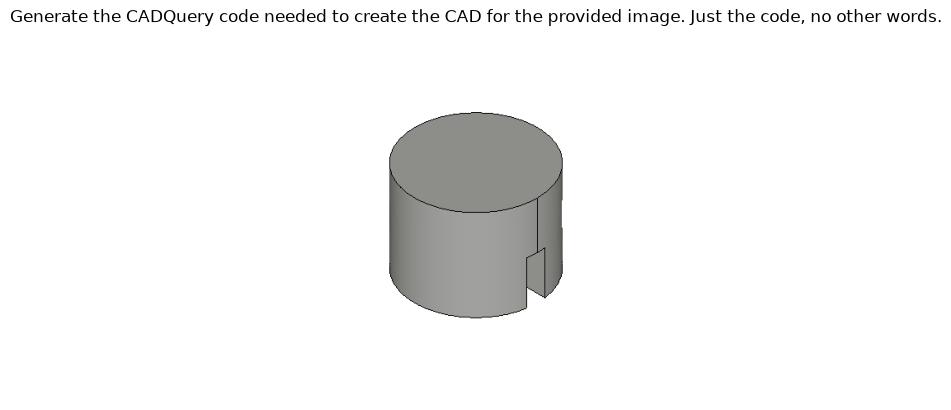

CadQuery code:
import cadquery as cq
# Generating a workplane for sketch 0
wp_sketch0 = cq.Workplane(cq.Plane(cq.Vector(-0.5, 0.0, 0.0), cq.Vector(1.0, 0.0, 0.0), cq.Vector(0.0, 0.0, 1.0)))
loop0=wp_sketch0.moveTo(0.5052631578947369, 0.0).circle(0.5052631578947369)
solid0=wp_sketch0.add(loop0).extrude(0.75)
solid=solid0
# Generating a workplane for sketch 1
wp_sketch1 = cq.Workplane(cq.Plane(cq.Vector(0.0, -0.078125, 0.0), cq.Vector(3.749399456654644e-33, 1.0, -6.123233995736766e-17), cq.Vector(1.0, 0.0, 6.123233995736766e-17)))
loop1=wp_sketch1.moveTo(0.1475328947368421, 0.0).lineTo(0.1475328947368421, 0.359375).lineTo(0.0, 0.359375).lineTo(0.0, 0.0).close()
solid1=wp_sketch1.add(loop1).extrude(-1.0, both=True)
solid=solid.cut(solid1)
# Generating a workplane for sketch 2
wp_sketch2 = cq.Workplane(cq.Plane(cq.Vector(-0.140625, 0.0, 0.1484375), cq.Vector(1.0, 6.123233995736766e-17, -6.123233995736766e-17), cq.Vector(6.123233995736766e-17, -1.0, 6.123233995736766e-17)))
loop2=wp_sketch2

In [9]:
sample = ds[0][32]

plt.imshow(sample['image'])
plt.axis('off')
plt.title(sample['prompt'])
plt.show()

print("CadQuery code:")
print(sample['cadquery'])
print("\nToken count:", sample['token_count'])

In [5]:
import torch

In [8]:
import re
from collections import Counter
codes = torch.load("train.pt")["codes"]
skel = [re.sub(r"-?\d+\.?\d*", "N", c) for c in codes]
print("total:", len(codes))
print("unique code:", len(set(codes)))
print("unique skeletons:", len(set(skel)))

total: 10000
unique code: 8737
unique skeletons: 2333


In [4]:
train, test = ds
print(train)
print(train.features)
print(train[0])

Dataset({
    features: ['image', 'deepcad_id', 'cadquery', 'token_count', 'prompt', 'hundred_subset'],
    num_rows: 147289
})
{'image': Image(mode=None, decode=True, id=None), 'deepcad_id': Value(dtype='string', id=None), 'cadquery': Value(dtype='string', id=None), 'token_count': Value(dtype='int64', id=None), 'prompt': Value(dtype='string', id=None), 'hundred_subset': Value(dtype='bool', id=None)}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=448x448 at 0x27B7BE57B90>, 'deepcad_id': '0000/00006371', 'cadquery': 'import cadquery as cq\n# Generating a workplane for sketch 0\nwp_sketch0 = cq.Workplane(cq.Plane(cq.Vector(-0.015625, -0.0078125, 0.0), cq.Vector(1.0, 0.0, 0.0), cq.Vector(0.0, 0.0, 1.0)))\nloop0=wp_sketch0.moveTo(0.0, 0.0).threePointArc((0.0007948582418457166, -0.0019189575476279677), (0.0027138157894736844, -0.0027138157894736844)).lineTo(0.021217105263157895, -0.0027138157894736844).threePointArc((0.022787161438489866, -0.00206347722796355), (0.0234375, -

In [ ]:
from transformers import AutoTokenizer
codes = train.select_columns(["cadquery"])["cadquery"]
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")

lens = []
B = 1000
for i in range(0, len(codes), B):
    batch = codes[i:i+B]
    tokenized = tokenizer_gpt2(batch, truncation=False, padding=False)
    lens.extend([len(x) for x in tokenized["input_ids"]])
lens = np.array(lens)
print(np.percentile(lens, [50, 90, 95, 99, 99.9, 100]))
print((lens > 950).mean())

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1245 > 1024). Running this sequence through the model will result in indexing errors


[ 302.     942.    1192.    1710.    2126.712 3988.   ]
0.09832370373890786


In [ ]:
tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Coder-0.5B")

d:\CV\mecagent-technical-test\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vandi\.cache\huggingface\hub\models--Qwen--Qwen2.5-Coder-0.5B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [ ]:
lens = []
B = 1000
for i in range(0, len(codes), B):
    batch = codes[i:i+B]
    tokenized = tokenizer_qwen(batch, truncation=False, padding=False)
    lens.extend([len(x) for x in tokenized["input_ids"]])
lens = np.array(lens)
print(np.percentile(lens, [50, 90, 95, 99, 99.9, 100]))
print((lens > 950).mean())

[ 382. 1193. 1523. 2292. 2837. 5379.]
0.15833497409854097


In [ ]:
s = "cq.Workplane().box(47.35, 12.5, 8.125)"
print(tokenizer_gpt2.convert_ids_to_tokens(tokenizer_gpt2(s)["input_ids"]))
print(tokenizer_qwen.convert_ids_to_tokens(tokenizer_qwen(s)["input_ids"]))

['c', 'q', '.', 'Work', 'plane', '().', 'box', '(', '47', '.', '35', ',', 'Ġ12', '.', '5', ',', 'Ġ8', '.', '125', ')']
['cq', '.Work', 'plane', '().', 'box', '(', '4', '7', '.', '3', '5', ',', 'Ġ', '1', '2', '.', '5', ',', 'Ġ', '8', '.', '1', '2', '5', ')']
